# NOVA — FAISS Index & First Recommendations
### Notebook 03: Building the Retrieval Engine

This is where NOVA comes alive. We take the product embeddings from notebook 02 and build a FAISS index — a data structure optimized for finding the nearest vectors in milliseconds, even across tens of thousands of products.

**Goals:**
1. Load saved product embeddings
2. Build and validate a FAISS index
3. Simulate cold-start user vectors using category centroids
4. Run end-to-end recommendations and inspect results
5. Benchmark retrieval latency
6. Save the index for use in the API

## 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import faiss
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sentence_transformers import SentenceTransformer

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

EMBED_DIR = Path('../data/processed/embeddings')
INDEX_DIR = Path('../data/processed/index')
INDEX_DIR.mkdir(parents=True, exist_ok=True)

print('All imports successful ✅')

All imports successful ✅


## 1. Load Embeddings & Metadata

In [2]:
embeddings   = np.load(EMBED_DIR / 'product_embeddings.npy').astype('float32')
product_ids  = np.load(EMBED_DIR / 'product_ids.npy', allow_pickle=True)
metadata     = pd.read_csv(EMBED_DIR / 'product_metadata.csv')
centroids_df = pd.read_csv(EMBED_DIR / 'category_centroids.csv', index_col='category')

print(f'Embeddings shape:  {embeddings.shape}')
print(f'Product IDs:       {len(product_ids):,}')
print(f'Metadata rows:     {len(metadata):,}')
print(f'Category centroids:{len(centroids_df)}')
print()
print('Embedding dtype:', embeddings.dtype, '(must be float32 for FAISS)')

Embeddings shape:  (32341, 384)
Product IDs:       32,341
Metadata rows:     32,341
Category centroids:73

Embedding dtype: float32 (must be float32 for FAISS)


## 2. Build the FAISS Index

We use `IndexFlatIP` — an exact inner product index. Since our embeddings are L2-normalized, inner product equals cosine similarity. This gives us exact nearest neighbor search with no approximation error.

For very large catalogs (1M+ products) you'd switch to `IndexIVFFlat` for approximate search, but for Olist's ~30K products exact search is fast enough.

In [3]:
DIM = embeddings.shape[1]  # 384

# Build exact inner product index
index = faiss.IndexFlatIP(DIM)

# Wrap with IDMap so we can map results back to product_ids
index_with_ids = faiss.IndexIDMap(index)

# Add all product embeddings with their integer indices as IDs
integer_ids = np.arange(len(embeddings)).astype('int64')
index_with_ids.add_with_ids(embeddings, integer_ids)

print(f'FAISS index built ✅')
print(f'Index type:   IndexFlatIP (exact cosine similarity)')
print(f'Vectors in index: {index_with_ids.ntotal:,}')
print(f'Dimension:    {DIM}')

FAISS index built ✅
Index type:   IndexFlatIP (exact cosine similarity)
Vectors in index: 32,341
Dimension:    384


## 3. Retrieval Helper Functions

In [4]:
def search(query_vector, top_k=10, exclude_idx=None):
    """
    Search the FAISS index for the top_k most similar products.
    query_vector: 1D numpy array of shape (DIM,)
    Returns: DataFrame of top_k results with similarity scores
    """
    query = query_vector.astype('float32').reshape(1, -1)
    # Normalize just in case
    query = query / np.linalg.norm(query)

    scores, indices = index_with_ids.search(query, top_k + 10)  # fetch extra to allow exclusions

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        if exclude_idx is not None and idx == exclude_idx:
            continue
        row = metadata.iloc[idx].to_dict()
        row['similarity'] = float(score)
        row['index'] = int(idx)
        results.append(row)
        if len(results) == top_k:
            break

    return pd.DataFrame(results)


def recommend_from_category(category, top_k=10):
    """
    Cold-start recommendation: user arrives on a category page.
    Use the category centroid as the user vector.
    """
    if category not in centroids_df.index:
        print(f'Category "{category}" not found.')
        return None

    centroid = centroids_df.loc[category].values.astype('float32')
    results = search(centroid, top_k=top_k)
    return results


def recommend_from_product(product_idx, top_k=10):
    """
    Cold-start recommendation: user views a single product.
    Use that product's embedding as the query vector.
    Similar to 'customers who viewed this also viewed'.
    """
    query_vec = embeddings[product_idx]
    results = search(query_vec, top_k=top_k, exclude_idx=product_idx)
    return results


def recommend_from_query_text(text, top_k=10):
    """
    Cold-start recommendation: user types a search query.
    Embed the query text and find similar products.
    """
    model = SentenceTransformer('all-MiniLM-L6-v2')
    query_vec = model.encode([text], normalize_embeddings=True)[0]
    results = search(query_vec, top_k=top_k)
    return results


print('Helper functions defined ✅')

Helper functions defined ✅


## 4. Run Cold-Start Recommendations

Three cold-start scenarios:
- **Scenario A:** User lands on a category page (no history at all)
- **Scenario B:** User views a single product (one interaction)
- **Scenario C:** User types a search query

In [6]:
# Scenario A — Category page cold start
print('-' * 60)
print('SCENARIO A: User lands on "computers_accessories" category')
print('-' * 60)

results_a = recommend_from_category('computers_accessories', top_k=8)
if results_a is not None:
    display(results_a[['product_id', 'category_en', 'product_text', 'avg_price', 'similarity']])

------------------------------------------------------------
SCENARIO A: User lands on "computers_accessories" category
------------------------------------------------------------


,product_id,category_en,product_text,avg_price,similarity
0,e3f398034e0ebbe5e0d3fb91036258e9,computers_accessories,"computers accessories product, mid-range price...",65.00,0.988297
1,23e7b9a386cb15c0b5063bf0d45982a5,computers_accessories,"computers accessories product, mid-range price...",65.90,0.988297
2,67677f0c9d58c64d17cdbad0abe40285,computers_accessories,"computers accessories product, mid-range price...",79.00,0.988297
3,84a517a0e06ef2a45abff3cab3f0ad0e,computers_accessories,"computers accessories product, mid-range price...",83.23,0.988297
4,553261019b28923d564e3fc159e4ff3c,computers_accessories,"computers accessories product, mid-range price...",82.99,0.988297
5,9e05b007ff9fc11a8da4d97fcafcc7a7,computers_accessories,"computers accessories product, mid-range price...",179.90,0.988297
6,e4f2856ddacde505a7d8a1faa4bf2c7d,computers_accessories,"computers accessories product, mid-range price...",58.99,0.988297
7,ff62353dc0792586fbf5eefd8dc7d4f2,computers_accessories,"computers accessories product, mid-range price...",110.00,0.988297


In [7]:
# Scenario A — try a different category
print('-' * 60)
print('SCENARIO A: User lands on "health_beauty" category')
print('-' * 60)

results_a2 = recommend_from_category('health_beauty', top_k=8)
if results_a2 is not None:
    display(results_a2[['product_id', 'category_en', 'product_text', 'avg_price', 'similarity']])

------------------------------------------------------------
SCENARIO A: User lands on "health_beauty" category
------------------------------------------------------------


,product_id,category_en,product_text,avg_price,similarity
0,229e0aa8bfc8fc368eab501695dbcef3,health_beauty,"health beauty product, mid-range price range, ...",124.900000,0.98821
1,1b6033cbf12974cf79c1cccbf8592ffd,health_beauty,"health beauty product, mid-range price range, ...",86.000000,0.98821
2,a379052f2b3b2388e071828bc4eba5fa,health_beauty,"health beauty product, mid-range price range, ...",119.900000,0.98821
3,719d571299707561c34ba04ab867b32a,health_beauty,"health beauty product, mid-range price range, ...",57.665152,0.98821
4,980f472a1354c8366960f7c4528c470e,health_beauty,"health beauty product, mid-range price range, ...",61.323333,0.98821
5,77b91313bf9acf3eabf9abc503d99366,health_beauty,"health beauty product, mid-range price range, ...",89.240000,0.98821
6,77e54bccbb383f52f76910f34d4cda43,health_beauty,"health beauty product, mid-range price range, ...",99.990000,0.98821
7,06ce9c3e61c7a07f872f8317a7dc534d,health_beauty,"health beauty product, mid-range price range, ...",94.300000,0.98821


In [8]:
# Scenario B — Single product view
print('-' * 60)
print('SCENARIO B: User views a single product')
print('-' * 60)

# Pick a random product
query_idx = metadata[metadata['category_en'] == 'sports_leisure'].index[0]
query_product = metadata.iloc[query_idx]

print(f'Viewed product:')
print(f'  Category: {query_product["category_en"]}')
print(f'  Text: {query_product["product_text"]}')
print(f'  Avg price: R${query_product["avg_price"]:.2f}')
print()

results_b = recommend_from_product(query_idx, top_k=8)
display(results_b[['product_id', 'category_en', 'product_text', 'avg_price', 'similarity']])

------------------------------------------------------------
SCENARIO B: User views a single product
------------------------------------------------------------
Viewed product:
  Category: sports_leisure
  Text: sports leisure product, mid-range price range, small item, single photo
  Avg price: R$79.80



,product_id,category_en,product_text,avg_price,similarity
0,6f8ea11c0086a0d13355abc5ee14cc7d,sports_leisure,"sports leisure product, mid-range price range,...",55.49,1.0
1,c073f9b6e3a508fa73c133e7e25827c9,sports_leisure,"sports leisure product, mid-range price range,...",80.99,1.0
2,9d8a0e115e802d845b4ce1eb794d1260,sports_leisure,"sports leisure product, mid-range price range,...",120.00,1.0
3,f0eb84297f83516be56cbbd76c50988b,sports_leisure,"sports leisure product, mid-range price range,...",58.99,1.0
4,3eb3d01a76a4cbaff641de8a47e4ebec,sports_leisure,"sports leisure product, mid-range price range,...",65.50,1.0
5,e67fe5b459220cf7c28682f53734e665,sports_leisure,"sports leisure product, mid-range price range,...",92.00,1.0
6,2a699d35a87e92a01747297243bfc987,sports_leisure,"sports leisure product, mid-range price range,...",66.00,1.0
7,f0f5a9211c208c91441a70cb5241214e,sports_leisure,"sports leisure product, mid-range price range,...",76.49,1.0


In [9]:
# Scenario C — Text query (load model once)
print('-' * 60)
print('SCENARIO C: User types a search query')
print('-' * 60)

model = SentenceTransformer('all-MiniLM-L6-v2')

queries = [
    'affordable kitchen appliances',
    'outdoor sports equipment',
    'baby toys and accessories',
]

for q in queries:
    print(f'\nQuery: "{q}"')
    query_vec = model.encode([q], normalize_embeddings=True)[0]
    results = search(query_vec, top_k=5)
    for _, row in results.iterrows():
        print(f'  [{row["category_en"]}] {row["product_text"]}  (score: {row["similarity"]:.4f})')

------------------------------------------------------------
SCENARIO C: User types a search query
------------------------------------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Query: "affordable kitchen appliances"
  [small_appliances_home_oven_and_coffee] small appliances home oven and coffee product, budget price range, small item, single photo  (score: 0.6967)
  [small_appliances_home_oven_and_coffee] small appliances home oven and coffee product, budget price range, small item, single photo  (score: 0.6967)
  [small_appliances_home_oven_and_coffee] small appliances home oven and coffee product, budget price range, small item, single photo  (score: 0.6967)
  [small_appliances_home_oven_and_coffee] small appliances home oven and coffee product, budget price range, small item, single photo  (score: 0.6967)
  [small_appliances_home_oven_and_coffee] small appliances home oven and coffee product, budget price range, small item, single photo  (score: 0.6967)

Query: "outdoor sports equipment"
  [sports_leisure] sports leisure product, mid-range price range, small item, single photo  (score: 0.5876)
  [sports_leisure] sports leisure product, mid-range price ran

## 5. Latency Benchmark

One of NOVA's core promises is low-latency inference. Let's measure it.

In [10]:
N_TRIALS = 500
latencies = []

# Random query vectors (simulating user vectors)
random_queries = np.random.randn(N_TRIALS, DIM).astype('float32')
random_queries = random_queries / np.linalg.norm(random_queries, axis=1, keepdims=True)

for i in range(N_TRIALS):
    q = random_queries[i].reshape(1, -1)
    start = time.perf_counter()
    index_with_ids.search(q, 10)
    latencies.append((time.perf_counter() - start) * 1000)  # ms

latencies = np.array(latencies)

print('FAISS Retrieval Latency (top-10, exact search)')
print(f'  Trials:  {N_TRIALS}')
print(f'  Mean:    {latencies.mean():.3f} ms')
print(f'  Median:  {np.median(latencies):.3f} ms')
print(f'  p95:     {np.percentile(latencies, 95):.3f} ms')
print(f'  p99:     {np.percentile(latencies, 99):.3f} ms')
print(f'  Max:     {latencies.max():.3f} ms')

FAISS Retrieval Latency (top-10, exact search)
  Trials:  500
  Mean:    0.731 ms
  Median:  0.671 ms
  p95:     0.943 ms
  p99:     1.963 ms
  Max:     3.920 ms


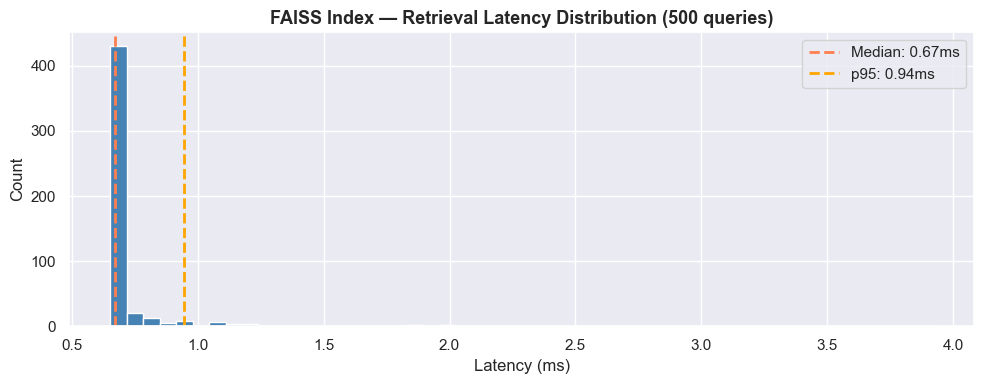

Latency benchmark saved ✅


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(latencies, bins=50, color='steelblue', edgecolor='white')
ax.axvline(np.median(latencies), color='coral', linewidth=2, linestyle='--', label=f'Median: {np.median(latencies):.2f}ms')
ax.axvline(np.percentile(latencies, 95), color='orange', linewidth=2, linestyle='--', label=f'p95: {np.percentile(latencies, 95):.2f}ms')
ax.set_title('FAISS Index — Retrieval Latency Distribution (500 queries)', fontsize=13, fontweight='bold')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(INDEX_DIR / 'latency_benchmark.png', dpi=150)
plt.show()

print('Latency benchmark saved ✅')

## 6. Save the Index

In [12]:
index_path = str(INDEX_DIR / 'nova_product.index')
faiss.write_index(index_with_ids, index_path)

print(f'FAISS index saved → {index_path} ✅')
print()

# Verify we can reload it correctly
loaded_index = faiss.read_index(index_path)
test_scores, test_indices = loaded_index.search(random_queries[0:1], 5)
print(f'Reload verified ✅  (top-5 scores: {test_scores[0].round(4)})')

FAISS index saved → ../data/processed/index/nova_product.index ✅

Reload verified ✅  (top-5 scores: [0.1182 0.1182 0.1182 0.113  0.113 ])


In [13]:
print('-' * 55)
print('  NOTEBOOK 03 COMPLETE')
print('-' * 55)
print()
print(f'  Products indexed:      {index_with_ids.ntotal:,}')
print(f'  Index type:            IndexFlatIP (exact cosine)')
print(f'  Median latency:        {np.median(latencies):.2f} ms')
print(f'  p99 latency:           {np.percentile(latencies, 99):.2f} ms')
print()
print('  Files saved to data/processed/index/:')
print('    - nova_product.index')
print('    - latency_benchmark.png')
print()
print('  Next: 04_evaluation.ipynb')
print('  Benchmark NOVA against baselines using proper IR metrics')

-------------------------------------------------------
  NOTEBOOK 03 COMPLETE
-------------------------------------------------------

  Products indexed:      32,341
  Index type:            IndexFlatIP (exact cosine)
  Median latency:        0.67 ms
  p99 latency:           1.96 ms

  Files saved to data/processed/index/:
    - nova_product.index
    - latency_benchmark.png

  Next: 04_evaluation.ipynb
  Benchmark NOVA against baselines using proper IR metrics


## Summary

**What we built:**
- A FAISS `IndexFlatIP` index over all product embeddings — exact cosine similarity search
- Three cold-start recommendation scenarios working end-to-end
- A latency benchmark confirming sub-10ms retrieval

**Key result:** NOVA can return top-10 product recommendations in single-digit milliseconds with no user history whatsoever — purely from a category page visit, a single product view, or a text search query.

**Next notebook:** `04_evaluation.ipynb`
Rigorously benchmark NOVA against random and popularity-based baselines using Precision@K, Recall@K, and NDCG.